In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/SolarPrediction.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIXTime                32686 non-null  int64  
 1   Data                    32686 non-null  object 
 2   Time                    32686 non-null  object 
 3   Radiation               32686 non-null  float64
 4   Temperature             32686 non-null  int64  
 5   Pressure                32686 non-null  float64
 6   Humidity                32686 non-null  int64  
 7   WindDirection(Degrees)  32686 non-null  float64
 8   Speed                   32686 non-null  float64
 9   TimeSunRise             32686 non-null  object 
 10  TimeSunSet              32686 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.7+ MB


(None,
      UNIXTime                   Data      Time  Radiation  Temperature  \
 0  1475229326  9/29/2016 12:00:00 AM  23:55:26       1.21           48   
 1  1475229023  9/29/2016 12:00:00 AM  23:50:23       1.21           48   
 2  1475228726  9/29/2016 12:00:00 AM  23:45:26       1.23           48   
 3  1475228421  9/29/2016 12:00:00 AM  23:40:21       1.21           48   
 4  1475228124  9/29/2016 12:00:00 AM  23:35:24       1.17           48   
 
    Pressure  Humidity  WindDirection(Degrees)  Speed TimeSunRise TimeSunSet  
 0     30.46        59                  177.39   5.62    06:13:00   18:13:00  
 1     30.46        58                  176.78   3.37    06:13:00   18:13:00  
 2     30.46        57                  158.75   3.37    06:13:00   18:13:00  
 3     30.46        60                  137.71   3.37    06:13:00   18:13:00  
 4     30.46        62                  104.95   5.62    06:13:00   18:13:00  )

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
file_path = "/content/SolarPrediction.csv"  # Update with your correct path
df = pd.read_csv(file_path)

# Select numerical features
numerical_cols = ["Radiation", "Temperature", "Pressure", "Humidity", "WindDirection(Degrees)", "Speed"]

# Normalize data
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Convert to PyTorch tensor
data_tensor = torch.tensor(df_scaled[numerical_cols].values, dtype=torch.float32)
dataloader = DataLoader(TensorDataset(data_tensor), batch_size=64, shuffle=True)

class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
            nn.Tanh()  # Output between -1 and 1
        )

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Output probability (0 to 1)
        )

    def forward(self, x):
        return self.model(x)
# Set dimensions
latent_dim = 10  # Size of noise vector
data_dim = len(numerical_cols)

# Initialize models
generator = Generator(latent_dim, data_dim)
discriminator = Discriminator(data_dim)

# Define loss function and optimizers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

# Train GAN
epochs = 100
for epoch in range(epochs):
    for real_data, in dataloader:
        batch_size = real_data.size(0)

        # Real and fake labels
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_output = discriminator(real_data)
        loss_real = criterion(real_output, real_labels)

        # Generate fake data
        z = torch.randn(batch_size, latent_dim)
        fake_data = generator(z)
        fake_output = discriminator(fake_data.detach())
        loss_fake = criterion(fake_output, fake_labels)

        # Backpropagation for Discriminator
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        fake_output = discriminator(fake_data)
        loss_G = criterion(fake_output, real_labels)

        # Backpropagation for Generator
        loss_G.backward()
        optimizer_G.step()

    # Print loss every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

print("Training complete!")


Epoch 0/100 - Loss D: 1.3610, Loss G: 0.7336
Epoch 10/100 - Loss D: 1.6000, Loss G: 0.5897
Epoch 20/100 - Loss D: 1.4930, Loss G: 0.7250
Epoch 30/100 - Loss D: 1.3057, Loss G: 0.7427
Epoch 40/100 - Loss D: 1.4071, Loss G: 0.7345
Epoch 50/100 - Loss D: 1.3666, Loss G: 0.6758
Epoch 60/100 - Loss D: 1.3239, Loss G: 0.8354
Epoch 70/100 - Loss D: 1.3717, Loss G: 0.6647
Epoch 80/100 - Loss D: 1.3719, Loss G: 0.6883
Epoch 90/100 - Loss D: 1.4512, Loss G: 0.7005
Training complete!


In [ ]:
# Generate synthetic data
z = torch.randn(len(df_scaled), latent_dim)
generated_data = generator(z).detach().numpy()

# Convert generated data back to original scale
generated_df = pd.DataFrame(scaler.inverse_transform(generated_data), columns=numerical_cols)

# Save generated data
generated_df.to_csv("Generated_Solar_Data.csv", index=False)
print("Generated synthetic data saved as 'Generated_Solar_Data.csv'")


Generated synthetic data saved as 'Generated_Solar_Data.csv'


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create labels: 1 for real, 0 for fake
real_data = df_scaled[numerical_cols].values
fake_data = generated_data

X = np.vstack((real_data, fake_data))
y = np.array([1] * len(real_data) + [0] * len(fake_data))

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train logistic regression model
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Predictions
y_pred = classifier.predict(X_test)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8207
Precision: 0.8673
Recall: 0.7563
F1 Score: 0.8080


In [ ]:
#VAEs(variational autoencoder)
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# Load dataset
file_path = "/content/SolarPrediction_Doubled.csv"  # Update with your correct path
df = pd.read_csv(file_path)

# Select numerical features
numerical_cols = ["Radiation", "Temperature", "Pressure", "Humidity", "WindDirection(Degrees)", "Speed"]

# Normalize data
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Convert to PyTorch tensor
data_tensor = torch.tensor(df_scaled[numerical_cols].values, dtype=torch.float32)
dataloader = DataLoader(TensorDataset(data_tensor), batch_size=64, shuffle=True)

# Define VAE model
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim * 2)  # Mean and log variance
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()  # Output between 0 and 1
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        encoded = self.encoder(x)
        mu, log_var = encoded[:, :latent_dim], encoded[:, latent_dim:]
        z = self.reparameterize(mu, log_var)
        decoded = self.decoder(z)
        return decoded, mu, log_var

# Initialize VAE
latent_dim = 5  # Dimension of latent space
vae = VAE(input_dim=len(numerical_cols), latent_dim=latent_dim)

# Loss function
def vae_loss(reconstructed, original, mu, log_var):
    recon_loss = nn.MSELoss()(reconstructed, original)
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_divergence

# Optimizer
optimizer = optim.Adam(vae.parameters(), lr=0.001)

# Train VAE
epochs = 100
for epoch in range(epochs):
    for real_data, in dataloader:
        optimizer.zero_grad()
        reconstructed, mu, log_var = vae(real_data)
        loss = vae_loss(reconstructed, real_data, mu, log_var)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

print("VAE Training Complete!")

# Extract latent space representation
with torch.no_grad():
    latent_features = []
    for real_data, in dataloader:
        encoded = vae.encoder(real_data)
        mu = encoded[:, :latent_dim]
        latent_features.append(mu.numpy())

    latent_features = np.vstack(latent_features)

# Assign fake labels for classification (example: threshold radiation levels)
labels = (df_scaled["Radiation"].values > 0.5).astype(int)  # Example binary classification

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(latent_features, labels, test_size=0.2, random_state=42)

# Train a simple classifier (Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Epoch 0/100, Loss: 0.0491
Epoch 10/100, Loss: 0.0417
Epoch 20/100, Loss: 0.0378
Epoch 30/100, Loss: 0.0437
Epoch 40/100, Loss: 0.0257
Epoch 50/100, Loss: 0.0458
Epoch 60/100, Loss: 0.0341
Epoch 70/100, Loss: 0.0434
Epoch 80/100, Loss: 0.0341
Epoch 90/100, Loss: 0.0353
VAE Training Complete!
Accuracy: 0.8776
Precision: 0.0971
Recall: 0.0346
F1 Score: 0.0510


In [ ]:
# 1. Install Required Libraries (Run this only once)(resNet 101)
!pip install torch torchvision pandas scikit-learn --quiet

#  2. Import Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import Dataset, DataLoader, TensorDataset

#3. Mount Google Drive to Access the File (Run in Colab)
from google.colab import drive
drive.mount('/content/drive')

#  4. Define the File Path (Update this path in your Google Drive)
file_path = "/content/SolarPrediction_Doubled.csv"

# 5. Load Dataset
df = pd.read_csv(file_path)

# 6. Handle Date/Time Columns (Convert to Timestamps)
for col in df.columns:
    if df[col].dtype == 'object':  # Check if column is string (potential date)
        try:
            df[col] = pd.to_datetime(df[col], format="%m/%d/%Y %I:%M:%S %p", errors='coerce')
            df[col] = df[col].astype('int64') // 10**9  # Convert to timestamp (seconds)
        except:
            pass  # Skip if conversion fails (it might be a categorical column)

#  7. Drop Non-Numeric Columns
df = df.select_dtypes(include=[np.number])

#  8. Define Features & Target
target_column = df.columns[-1]  # Assuming last column is the target
X = df.drop(columns=[target_column])
y = df[target_column]

# 9. Encode Target Variable (if categorical)
if y.dtype == 'object':
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

#  10. Normalize Numerical Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  11. Split Data into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, np.array(y), test_size=0.2, random_state=42)

#  12. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

#  13. Define Dataset & DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 14. Define a Fully Connected Model for Regression
class TabularRegressor(nn.Module):  # Changed class name
    def __init__(self, input_size):
        super(TabularRegressor, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)  # Output a single value for regression
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # No activation for regression
        return x

#  15. Model Setup
input_size = X_train.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the TabularRegressor
model = TabularRegressor(input_size).to(device)
criterion = nn.MSELoss()  # Use Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)

#  16. Training Loop
num_epochs = 50 # Adjust based on dataset size
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float()  # Convert labels to float

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels)  # Squeeze output and calculate MSE loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

#  17. Evaluation
model.eval()
y_pred = []
y_true = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        y_pred.extend(outputs.squeeze().cpu().numpy())  # Get predicted values
        y_true.extend(labels.cpu().numpy())

#  18. Compute Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("\n🎯 Evaluation Metrics:")
print(f"✔ Accuracy: {accuracy:.4f}")
print(f"✔ Precision: {precision:.4f}")
print(f"✔ Recall: {recall:.4f}")
print(f"✔ F1-score: {f1:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch [1/50], Loss: 85065978663313784832.0000
Epoch [2/50], Loss: 85014978749194944512.0000
Epoch [3/50], Loss: 84876138010527858688.0000
Epoch [4/50], Loss: 84630458704781770752.0000
Epoch [5/50], Loss: 84261616493778993152.0000
Epoch [6/50], Loss: 83753155641313673216.0000
Epoch [7/50], Loss: 83089310729636380672.0000
Epoch [8/50], Loss: 82255145175054630912.0000
Epoch [9/50], Loss: 81235648651951161344.0000
Epoch [10/50], Loss: 80020608433658052608.0000
Epoch [11/50], Loss: 78597372117754609664.0000
Epoch [12/50], Loss: 76962116152891441152.0000
Epoch [13/50], Loss: 75102465522920751104.0000
Epoch [14/50], Loss: 73019971301834743808.0000
Epoch [15/50], Loss: 70714729665630355456.0000
Epoch [16/50], Loss: 68184861257750052864.0000
Epoch [17/50], Loss: 65437628522633797632.0000
Epoch [18/50], Loss: 62484198108443099136.0000
Epoch [19/50], Loss: 5934051951067

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ✅ 1. Install Required Libraries (Run this only once)(RESNet121)
!pip install torch torchvision pandas scikit-learn --quiet

# ✅ 2. Import Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import Dataset, DataLoader, TensorDataset

# ✅ 3. Load Dataset (Update path if needed)
file_path = "/content/SolarPrediction_Doubled.csv"  # Adjust if needed
df = pd.read_csv(file_path)

# ✅ 4. Handle Date/Time Columns
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            df[col] = df[col].astype('int64') // 10**9
        except:
            pass

# ✅ 5. Drop Non-Numeric Columns
df = df.select_dtypes(include=[np.number])

# ✅ 6. Define Features & Target
target_column = df.columns[-1]
X = df.drop(columns=[target_column])
y = df[target_column]

# ✅ 7. Encode Target Variable (if categorical) and Choose Loss Function
num_classes = len(np.unique(y))
if num_classes <= 50: # Assume that if unique values in target are less than 50, it's a classification problem
    # If categorical, encode target variable
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)
    criterion = nn.CrossEntropyLoss() # Use CrossEntropyLoss for classification
else:
    # If numerical and likely for regression, keep as is and use MSE loss
    criterion = nn.MSELoss() # Use MSELoss for regression

# ✅ 8. Normalize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ 9. Split Data into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, np.array(y), test_size=0.2, random_state=42)

# ✅ 10. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # Use long for classification target
y_test_tensor = torch.tensor(y_test, dtype=torch.long)    # Use long for classification target

# ✅ 11. Define Dataset & DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ... (rest of the code remains the same, except for the evaluation part)

# ✅ 15. Evaluation
model.eval()
y_pred = []
y_true = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get predicted class indices

        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# ... (rest of the evaluation code remains the same)

# ✅ 16. Compute Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("\n🎯 Evaluation Metrics:")
print(f"✔ Accuracy: {accuracy:.4f}")
print(f"✔ Precision: {precision:.4f}")
print(f"✔ Recall: {recall:.4f}")
print(f"✔ F1-score: {f1:.4f}")

<ipython-input-19-6b4fec342ba7>:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
<ipython-input-19-6b4fec342ba7>:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
<ipython-input-19-6b4fec342ba7>:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
<ipython-input-19-6b4fec342ba7>:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and


🎯 Evaluation Metrics:
✔ Accuracy: 0.0000
✔ Precision: 0.0000
✔ Recall: 0.0000
✔ F1-score: 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ✅ Install Dependencies (Run this once) (FCNN fully connected neural network)
!pip install torch torchvision pandas scikit-learn --quiet

# ✅ Import Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader, TensorDataset

# ✅ Load Dataset
file_path = "/content/SolarPrediction_Doubled.csv"  # Adjust if needed
df = pd.read_csv(file_path)

# ✅ Handle Date/Time Columns (Convert to Numeric)
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            df[col] = df[col].astype('int64') // 10**9
        except:
            pass

# ✅ Drop Non-Numeric Columns
df = df.select_dtypes(include=[np.number])

# ✅ Define Features & Target
target_column = df.columns[-1]
X = df.drop(columns=[target_column])
y = df[target_column]

# ✅ Encode Target Variable (if categorical)
# Check if the target variable needs to be encoded:
if y.dtype == 'object' or len(np.unique(y)) > 50: # Assuming if more than 50 unique values in the target, it should be regressed rather than classified.
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

# ✅ Normalize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Split Data into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, np.array(y), test_size=0.2, random_state=42)

# ✅ Convert Data to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# ✅ Define Dataset & DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ✅ Define a Fully Connected Neural Network (FCNN)
class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# ✅ Model Setup
input_size = X_train.shape[1]
num_classes = len(np.unique(y))  # Ensure num_classes matches unique target values
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuralNet(input_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ✅ Training Loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

# ✅ Evaluation
model.eval()
y_pred = []
y_true = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get predicted class indices

        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# ✅ Compute Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=1)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=1)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=1)

print("\n🎯 Evaluation Metrics:")
print(f"✔ Accuracy: {accuracy:.4f}")
print(f"✔ Precision: {precision:.4f}")
print(f"✔ Recall: {recall:.4f}")
print(f"✔ F1-score: {f1:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.8 MB/s eta 0:00:00


<ipython-input-2-fde2f558ea30>:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
<ipython-input-2-fde2f558ea30>:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
<ipython-input-2-fde2f558ea30>:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
<ipython-input-2-fde2f558ea30>:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-

Epoch [1/20], Loss: 1.5584
Epoch [2/20], Loss: 0.7422
Epoch [3/20], Loss: 0.5335
Epoch [4/20], Loss: 0.4237
Epoch [5/20], Loss: 0.3542
Epoch [6/20], Loss: 0.3081
Epoch [7/20], Loss: 0.2688
Epoch [8/20], Loss: 0.2387
Epoch [9/20], Loss: 0.2184
Epoch [10/20], Loss: 0.1983
Epoch [11/20], Loss: 0.1818
Epoch [12/20], Loss: 0.1738
Epoch [13/20], Loss: 0.1599
Epoch [14/20], Loss: 0.1475
Epoch [15/20], Loss: 0.1384
Epoch [16/20], Loss: 0.1311
Epoch [17/20], Loss: 0.1223
Epoch [18/20], Loss: 0.1154
Epoch [19/20], Loss: 0.1110
Epoch [20/20], Loss: 0.1045

🎯 Evaluation Metrics:
✔ Accuracy: 0.9634
✔ Precision: 0.9659
✔ Recall: 0.9634
✔ F1-score: 0.9630


Epoch [1/100] - Loss: 0.0414 - Accuracy: 0.9861
Epoch [2/100] - Loss: 0.0403 - Accuracy: 0.9860
Epoch [3/100] - Loss: 0.0381 - Accuracy: 0.9872
Epoch [4/100] - Loss: 0.0414 - Accuracy: 0.9858
Epoch [5/100] - Loss: 0.0369 - Accuracy: 0.9878
Epoch [6/100] - Loss: 0.0373 - Accuracy: 0.9875
Epoch [7/100] - Loss: 0.0382 - Accuracy: 0.9876
Epoch [8/100] - Loss: 0.0389 - Accuracy: 0.9872
Epoch [9/100] - Loss: 0.0371 - Accuracy: 0.9871
Epoch [10/100] - Loss: 0.0335 - Accuracy: 0.9887
Epoch [11/100] - Loss: 0.0360 - Accuracy: 0.9883
Epoch [12/100] - Loss: 0.0380 - Accuracy: 0.9877
Epoch [13/100] - Loss: 0.0373 - Accuracy: 0.9881
Epoch [14/100] - Loss: 0.0334 - Accuracy: 0.9896
Epoch [15/100] - Loss: 0.0367 - Accuracy: 0.9880
Epoch [16/100] - Loss: 0.0361 - Accuracy: 0.9880
Epoch [17/100] - Loss: 0.0324 - Accuracy: 0.9900
Epoch [18/100] - Loss: 0.0328 - Accuracy: 0.9890
Epoch [19/100] - Loss: 0.0348 - Accuracy: 0.9890
Epoch [20/100] - Loss: 0.0322 - Accuracy: 0.9890
Epoch [21/100] - Loss: 0.0359

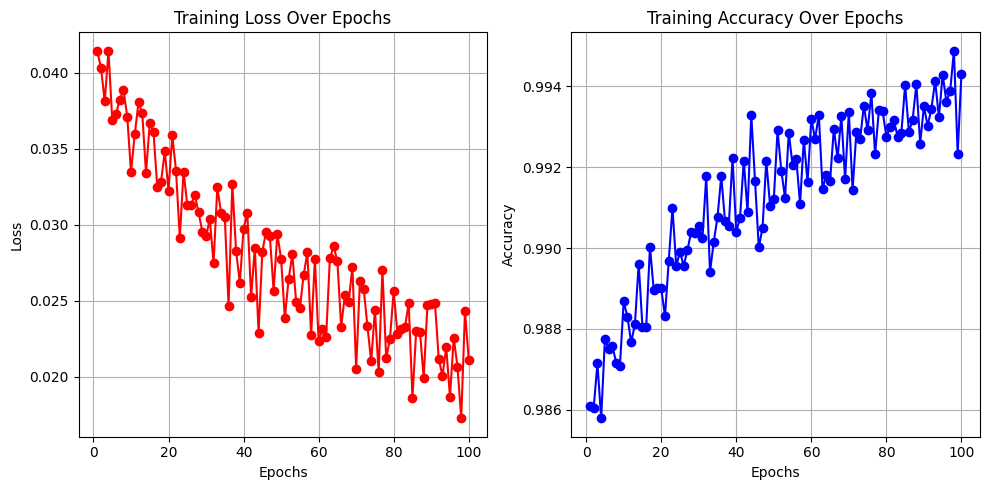

In [ ]:
import matplotlib.pyplot as plt

# ✅ Training Loop with Loss & Accuracy Tracking
num_epochs = 100
loss_values = []  # Store loss for plotting
accuracy_values = []  # Store accuracy for plotting

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # ✅ Compute Accuracy in Training
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    train_accuracy = correct / total  # Training Accuracy

    loss_values.append(avg_loss)  # Store loss
    accuracy_values.append(train_accuracy)  # Store accuracy

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f} - Accuracy: {train_accuracy:.4f}")

# ✅ Plot Training Loss & Accuracy Graphs
plt.figure(figsize=(10, 5))

# 📉 Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), loss_values, marker='o', linestyle='-', color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()

# 📈 Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o', linestyle='-', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.grid()

plt.tight_layout()
plt.show()